In [ ]:
# Instala las librerías necesarias para este notebook.

!pip install numpy scipy matplotlib qiskit pennylane pylatexenc

# Sesión 6 Laboratorio de Computación Cuántica 1

## Operador de Evolución temporal, evolución trotterizada y fidelidad de estados cuánticos

Una de las areas de exploración mas interesantes de la computación cuántica es la simulación de sistemas cuánticos y la evolución de estos con el pasar del tiempo. En la clase de hoy vamos a empezar a explorar 

### ¿Qué es un Hamiltoniano?

En mecánica cuántica, el Hamiltoniano es el operador que representa la energía de un sistema físico.

Se suele denotar como:

$$
H
$$

Si un sistema cuántico está en el estado $|\psi\rangle$, entonces la energía esperada de ese estado es:

$$
E(\psi) = \langle \psi | H | \psi \rangle
$$

El Hamiltoniano contiene la información del sistema que queremos estudiar. Por ejemplo, puede representar:

- La energía de una molécula.
- La interacción entre espines.
- Un sistema de partículas.
- Un problema de optimización escrito en lenguaje cuántico.

En computación cuántica, normalmente escribimos el Hamiltoniano como una combinación de operadores de Pauli:

$$
H = c_0 I + c_1 X + c_2 Y + c_3 Z + \cdots
$$

donde $X$, $Y$ y $Z$ son las matrices de Pauli.


## Evolución temporal de estados cuánticos

En mecánica cuántica, un estado cuántico $|\psi\rangle$ metido dentro de un sistema con Hamiltoniano H evoluciona gracias a dicho sistema con el tiempo usando la Ecuación de Schrodinger. 

$$i \hbar \frac{\partial}{\partial t}|\psi(t)\rangle = H |\psi(t)\rangle$$

donde:

- $|\psi(t)\rangle$ es el estado cuántico del sistema
- H es el Hamiltoniano
- $\hbar$ es la constante de planck reducida (en Computación Cuántica, la aproximamos a 1 por facilidad)
- i es la unidad imaginaria

Si el Hamiltoniano no depende del tiempo, esta ecuación tiene la siguiente solución:

$$|\psi(t)\rangle = e^{-iHt/\hbar}|\psi(0)\rangle$$

y podemos aproximar $\hbar\approx 1 $ para recupuerar la ecuación:

$$|\psi(t)\rangle = e^{-iHt}|\psi(0)\rangle$$

A $e^{-iHt}$ se le conoce como el operador de evolución temporal, y lo que veremos hoy, es como implementar esta compuerta para diversos hamiltonianos distintos usando las herramientas de la computación cuántica que conocemos


## Recordatorio: Las compuertas de rotación

Probablemente al ver la ecuación anterior te preguntaste ¿Como podemos aplicar una rotación sobre un sistema? La respuesta es sorprendentemente simple. Basicamente cualquie libreria que simule o trabaje con computación cuántica (lo veremos en qiskit y pennylane) tiene de opción aplicar las **Matrices de rotación**, que basicamente son operadores que aplican una rotación sobre X,Y y Z al sistema en la esfera de Bloch, y se visualizan como una exponencial con una matriz de Paulli. Aquí coloco sus expresiones para que las recuerdes cuando las necesites

#### Rotación en X

$$
R_x(\theta)
=
e^{-i\frac{\theta}{2}X}
$$

$$
R_x(\theta)
=
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right)
&
-i\sin\left(\frac{\theta}{2}\right)
\\[6pt]
-i\sin\left(\frac{\theta}{2}\right)
&
\cos\left(\frac{\theta}{2}\right)
\end{pmatrix}
$$


#### Rotación en Y

$$
R_y(\theta)
=
e^{-i\frac{\theta}{2}Y}
$$

$$
R_y(\theta)
=
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right)
&
-\sin\left(\frac{\theta}{2}\right)
\\[6pt]
\sin\left(\frac{\theta}{2}\right)
&
\cos\left(\frac{\theta}{2}\right)
\end{pmatrix}
$$


#### Rotación en Z

$$
R_z(\theta)
=
e^{-i\frac{\theta}{2}Z}
$$

$$
R_z(\theta)
=
\begin{pmatrix}
e^{-i\theta/2}
&
0
\\[6pt]
0
&
e^{i\theta/2}
\end{pmatrix}
$$

## Ejemplo de simulacion de Hamiltonianos de una sola compuerta

Supongamos que queremos simular un Hamiltoniano $H=X$, el operador de evolución temporal es entonces $e^{-iXt}$, recordando la matriz de rotación en x, $R_x(\theta)=e^{-i\frac{\theta}{2}X}$ de donde, si corremos la matriz de rotación para $\theta=2t$, entonces con eso hemos simulado el circuito. Análogamente para Y y Z. Veamoslo:

Estado final:
Statevector([0.38205142-0.59500984j, 0.38205142-0.59500984j],
            dims=(2,))


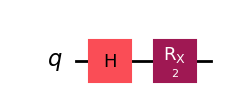

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Tiempo
t = 1.0

qc = QuantumCircuit(1)

#Define el estado inicial:

qc.h(0) #Usamos el estado +

#Evolución temporal:
qc.rx(2 * t, 0)

# Obtener estado final
psi = Statevector.from_instruction(qc)

print("Estado final:")
print(psi)

qc.draw("mpl")

# Hamiltonianos de 2 qubits

Imagina que tienes un hamiltoniano $H=Z \otimes I$, $H= I \otimes Z$ o $H = Z\otimes Z$, Las primeras 2 son bastante faciles, solo opera $R_z(2t)$ en el qubit que desees aplicar la compuerta. ¿Pero, y la última?

Qiskit tiene de opción el aplicar las compuertas $R_{ZZ}(\theta)=e^{-i\frac{\theta}{2}Z\otimes Z}, R_{XX}(\theta)=e^{-i\frac{\theta}{2}X\otimes X}$ y $R_{YY}(\theta)=e^{-i\frac{\theta}{2}Y\otimes Y}$. Y si deseas alguna combinación particularmente mas avanzada, puedes simplemente usar `PauliEvolutionGate` y la piblioteca `Pauli`, pero eso te tocara a ti investigarlo en tu tarea

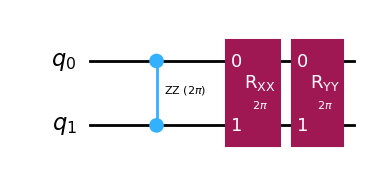

In [2]:
theta = 2*np.pi
qc = QuantumCircuit(2)

qc.rzz(theta, 0, 1)
qc.rxx(theta, 0, 1)
qc.ryy(theta, 0, 1)

qc.draw("mpl")

## La exponenciación de matrices y el problema de la conmutación

Te voy a proponer un Hamiltoniano muy sencillo: $H=aZ+bX$. Queremos evolucionar el estado y verificar como encontrarlo. El operador de evolución temporal parece muy simple, pues es de la siguiente forma:

$$e^{-i(aZ+bX)t}$$

Parecería simple ¿no?

Creo que la definición de exponencial de un número real es muy clara, pero ¿Que pasa con la exponenciación de una matriz? Pues asi como la exponencial real tiene su descomposición de taylor donde $e^x=1+x+\frac{x^2}{2!}+\frac{x^3}{3!}...+$, la exponenciación de matrices sigue exactamente el mismo principio. Si A es una matriz cuadrada, entonces 

$$e^A=1+A+\frac{A^2}{2!}+\frac{A^3}{3!}...+$$

Ahora, esto genera algunas propiedades muy interesantes, y es que utilizando la fórmula anterior, se puede demostrar que muchas de las propiedades de la exponencial de numeros reales, tambien se cumplen para la exponencial de matrices PERO CON UNA CONDICIÓN: Las matrices con las que operes deben conmutar, es decir $AB=BA$, similar a como los numeros reales conmutan. Una forma elegante de resumir esto es definir a $[A,B]=AB-BA$ como el **Conmutador** y decir que se cumplen diversas propiedades solo si las matrices en su interior conmutan

y una de estas propiedades es, incomodamente, la ley de los exponentes.

*Teorema: sean A y B 2 matrices tales que [A,B]=0. Entonces se cumple la siguiente propiedad*

$$e^{A+B}=e^{A}e^{B}$$

## Metodo de trotterización

La solución a la que trotter llegó es muy simple pero hermosa al mismo tiempo. Dijo: ¿Y si en lugar de trabajar el hamiltoniano sobre el t completo, lo dividimos en pedazos muy pequeños? Esto lo que hace es que se pueda "forzar" la separación de las 2 matrices debido a que el error con el cual se trabaje sea lo suficientemente bajo para el sistema.

La idea matemática es la siguiente: Imagina que queremos implementar $e^{-i(A+B)t}$. Primero, dividamos el tiempo en r intervalos, de manera que $\Delta t= \frac{t}{r}$.

Entonces tenemos la siguiente forma de evolución temporal:

$$e^{-i(A+B)t} = (e^{-i(A+B)\Delta t})^r$$

Hasta aquí nada raro, ¿verdad?

Entonces tomemos uno y solo uno de los intervalos de acción, y separemos la evolución de forma aproximada: $e^{-i(A+B)\Delta t} \approx e^{-iB\Delta t} e^{-iA\Delta t}$. Y si sustituimos esta aproximación en la ecuación anterior, llegamos a algo muy fuerte:

$e^{-i(A+B)t} \approx (e^{-iB \Delta t} e^{-iA \Delta t})^r $ 

donde $\Delta t=\frac{t}{r}$

y la igualdad se cumple en el limite donde r tiende a infinito

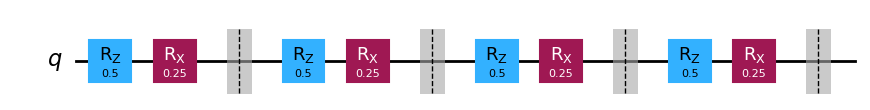

In [3]:
a = 1.0
b = 0.5
t = 1.0
r = 4

qc = QuantumCircuit(1)

dt = t / r

for _ in range(r):
    qc.rz(2*a*dt, 0)
    qc.rx(2*b*dt, 0)

    qc.barrier()

qc.draw("mpl")

Vamos a programarlo usando la segunda librería del curso que conocemos: Pennylane, para que veamos que potencial tiene esta librería para permitirnos recuperar valores interesantes del mismo:

In [4]:
import pennylane as qml
import numpy as np

dev = qml.device("default.qubit", wires=1) #Definimos el dispositivo de pennylane para trabajar

@qml.qnode(dev)  #Definimos el QNode
def evolucion_de_trotter(a, b, t, r):
    
    dt = t / r

    #Pon aqui el estado inicial:
    
    # Trotter 
    for _ in range(r):
        qml.RZ(2 * a * dt, 0)
        qml.RX(2 * b * dt, 0)

    return qml.state()


# Parámetros
a = 1.0
b = 0.5
t = 1.0
r = 4

psi = evolucion_de_trotter(a, b, t, r)  #Fijate como estamos tratando el procedimiento como una función a la que le recuperamos parámetros

print("Estado final:")
print(psi)

# Dibujar circuito
print(qml.draw(evolucion_de_trotter)(a, b, t, r))

Estado final:
[ 0.4395577 -0.80084249j -0.10062997-0.39409891j]
0: ──RZ(0.50)──RX(0.25)──RZ(0.50)──RX(0.25)──RZ(0.50)──RX(0.25)──RZ(0.50)──RX(0.25)─┤  State


## Fidelidad de estados cuánticos

Ya sabemos construir una aproximación de la evolución temporal usando trotterización. Pero ahora aparece una pregunta importante: ¿qué tan cerca está el estado que obtuvimos del estado al que queríamos llegar? Para responderla vamos a usar la **fidelidad**.

Si tenemos dos estados puros $|\psi\rangle$ y $|\phi\rangle$, su fidelidad se define como:

$$F(|\psi\rangle,|\phi\rangle)=|\langle\psi|\phi\rangle|^2$$

Es decir, calculamos el producto interno de los dos estados y tomamos el cuadrado de su valor absoluto. El resultado siempre está entre 0 y 1: si la fidelidad vale 1, los estados representan el mismo estado físico (aunque uno tenga una fase global distinta); si vale 0, son ortogonales. Por ejemplo, la fidelidad entre $|0\rangle$ y $|+\rangle$ es $1/2$.

¿Cómo nos ayuda esto con Trotter? Si $H=A+B$, podemos comparar la evolución exacta con la que construimos usando $r$ intervalos:

$$|\psi_{\mathrm{exacta}}(t)\rangle=e^{-iHt}|\psi(0)\rangle$$

$$|\psi_r(t)\rangle=\left(e^{-iB t/r}e^{-iA t/r}\right)^r|\psi(0)\rangle$$

Entonces, la fidelidad que nos interesa es:

$$F_r(t)=|\langle\psi_{\mathrm{exacta}}(t)|\psi_r(t)\rangle|^2$$

En una simulación ideal, al aumentar $r$ esperamos que la aproximación se acerque al estado exacto y que la fidelidad tienda a 1. Así podemos medir, con un solo número, qué tan bien funciona nuestra trotterización para un tiempo y un número de pasos determinados.


### Comparación en Qiskit: Trotter contra la evolución exacta

Retomemos el Hamiltoniano $H=aZ+bX$ y el estado inicial $|0\rangle$. Construiremos las matrices $Z$ y $X$ directamente con NumPy para formar $H$.

La función `expm` de SciPy calcula la **exponencial de una matriz**: $e^A=I+A+A^2/2!+A^3/3!+\cdots$, donde $A^2$ significa multiplicar la matriz por sí misma. Si le pasamos $-iHt$, obtenemos la matriz del operador de evolución temporal $U(t)=e^{-iHt}$. Incorporaremos esa matriz a un circuito de Qiskit mediante `unitary` para usarlo como referencia.

En otro circuito aplicaremos $R_z(2a\Delta t)$ y después $R_x(2b\Delta t)$ en cada uno de los $r$ intervalos. Así implementamos $e^{-ibX\Delta t}e^{-iaZ\Delta t}$ por paso. Al final obtendremos los dos estados con `Statevector` y calcularemos su fidelidad.


In [ ]:
import numpy as np
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity

# Usamos el mismo Hamiltoniano y el mismo estado inicial |0> en ambos circuitos.
a, b, t = 1.0, 0.5, 1.0
r = 4
Z = np.array([[1, 0], [0, -1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
H = a * Z + b * X

# Operador exacto de evolución temporal, incorporado como una compuerta unitaria.
U_exacta = expm(-1j * H * t)
qc_exacta = QuantumCircuit(1)
qc_exacta.unitary(U_exacta, [0], label="U exacta")  #Colocamos la unitaria que acabamos de crear

def circuito_trotter(r):
    qc = QuantumCircuit(1)
    dt = t / r
    for _ in range(r):
        qc.rz(2 * a * dt, 0)
        qc.rx(2 * b * dt, 0)
    return qc

qc_trotter = circuito_trotter(r)
psi_exacta = Statevector.from_instruction(qc_exacta)
psi_trotter = Statevector.from_instruction(qc_trotter)
fidelidad = state_fidelity(psi_exacta, psi_trotter)  #Calcula la fidelidad entre 2 estados

print("Circuito exacto:")
print(qc_exacta.draw("text"))
print("Circuito trotterizado:")
print(qc_trotter.draw("text"))
print("Estado exacto:", np.round(psi_exacta.data, 6))
print("Estado trotterizado:", np.round(psi_trotter.data, 6))
print(f"Fidelidad con r={r}: {fidelidad:.6f}")


Circuito exacto:
   ┌──────────┐
q: ┤ U exacta ├
   └──────────┘
Circuito trotterizado:
   ┌─────────┐┌──────────┐┌─────────┐┌──────────┐┌─────────┐┌──────────┐»
q: ┤ Rz(0.5) ├┤ Rx(0.25) ├┤ Rz(0.5) ├┤ Rx(0.25) ├┤ Rz(0.5) ├┤ Rx(0.25) ├»
   └─────────┘└──────────┘└─────────┘└──────────┘└─────────┘└──────────┘»
«   ┌─────────┐┌──────────┐
«q: ┤ Rz(0.5) ├┤ Rx(0.25) ├
«   └─────────┘└──────────┘
Estado exacto: [ 0.437451-0.804307j -0.      -0.402153j]
Estado trotterizado: [ 0.439558-0.800842j -0.10063 -0.394099j]
Fidelidad con r=4: 0.991207


¿Qué pasa si usamos más pasos? Repitamos la comparación para distintos valores de $r$. En esta simulación ideal, la fidelidad se acerca a 1 al reducir el tamaño de cada intervalo.


In [6]:
print("Pasos de Trotter | Fidelidad")
for pasos in [1, 2, 4, 8, 16, 32]:
    psi_aproximada = Statevector.from_instruction(circuito_trotter(pasos))
    F = state_fidelity(psi_exacta, psi_aproximada)
    print(f"{pasos:16d} | {F:.6f}")


Pasos de Trotter | Fidelidad
               1 | 0.830803
               2 | 0.963009
               4 | 0.991207
               8 | 0.997846
              16 | 0.999466
              32 | 0.999867
